In [1]:
%run ./00_setup.ipynb
lease_pairs = pd.read_parquet(INTERIM_DIR / "lease_pairs.parquet")
units = pd.read_parquet(INTERIM_DIR / "units.parquet")
leases = pd.read_parquet(INTERIM_DIR / "leases.parquet")

listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns
Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns


## 6. Renewals vs new tenants, and the rules that apply in each province

### 6.1 Four segments: {QC, ON} × {renewal, turnover}
Yearly median growth per province, lease type and basis (contract / effective), with `n`.
The split matters because a renewal (same tenant) is governed by provincial rules; a turnover (new tenant) is priced at market.

In [2]:
growth_by_segment = (lease_pairs
                     .melt(id_vars=["lease_year", "province", "lease_type"],
                           value_vars=["growth_contract", "growth_effective"], var_name="rent_basis", value_name="growth")
                     .assign(rent_basis=lambda d: d.rent_basis.str.replace("growth_", "", regex=False))
                     .groupby(["lease_year", "province", "lease_type", "rent_basis"])
                     .growth.agg(pairs="size", median="median", mean="mean")
                     .reset_index())
segment_view = growth_by_segment[growth_by_segment.lease_year >= FIRST_ANALYSIS_YEAR].pivot_table(
    index="lease_year", columns=["rent_basis", "province", "lease_type"], values="median")
(segment_view * PCT).round(2)

rent_basis contract                           effective                          
province         ON               QC                 ON               QC         
lease_type  renewal turnover renewal turnover   renewal turnover renewal turnover
lease_year                                                                       
2018            NaN      NaN    3.00     1.03       NaN      NaN    2.66     1.03
2019            NaN      NaN    2.55     1.21       NaN      NaN    1.96     1.32
2020            NaN      NaN    3.43     2.05       NaN      NaN    3.28     2.32
2021            NaN      NaN    4.77     3.52       NaN      NaN    4.00     2.36
2022            NaN      NaN    5.69     4.22       NaN      NaN    4.92     3.40
2023            NaN      NaN    2.58     1.85       NaN      NaN    2.21     1.68
2024           2.97     4.94    2.94     4.84      1.33     3.21    1.40     2.52
2025           6.25     8.96    6.43     8.98      2.46     5.45    2.97     5.80

In [3]:
pair_counts = lease_pairs.groupby(["lease_year", "province", "lease_type"]).size().unstack(["province", "lease_type"]).fillna(0).astype(int)
pair_counts.loc[FIRST_ANALYSIS_YEAR:]

province        QC               ON         
lease_type renewal turnover renewal turnover
lease_year                                  
2018            47       41       0        0
2019            92       67       0        0
2020           200      131       0        0
2021           220      135       0        0
2022           226      126       0        0
2023           239      177       0        0
2024           355      235      67       41
2025           410      253      63       54

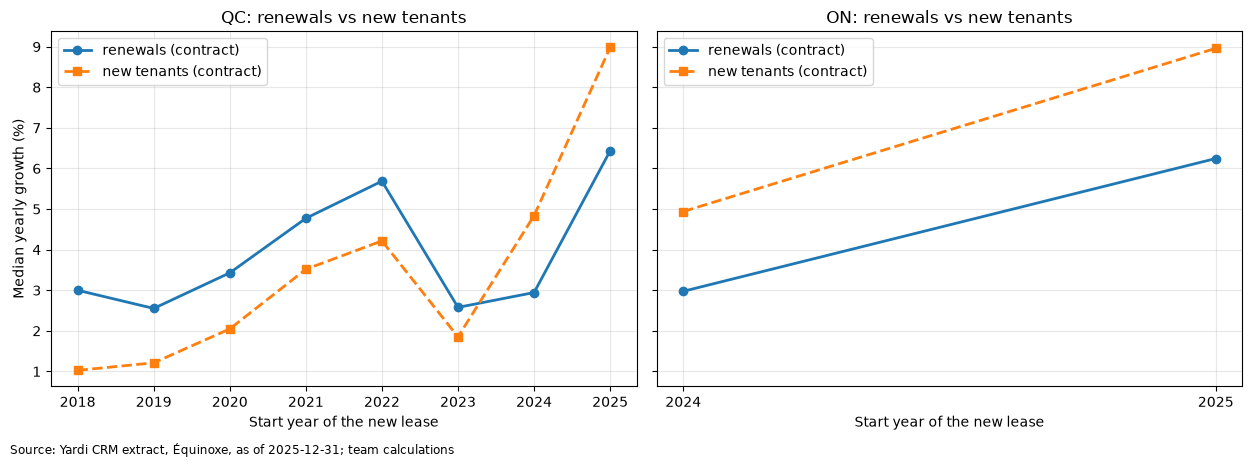

In [4]:
fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE, sharey=True)
for ax, province in zip(axes, ["QC", "ON"]):
    for lease_type, style in [("renewal", "o-"), ("turnover", "s--")]:
        series = growth_by_segment.query("province == @province and lease_type == @lease_type and rent_basis == 'contract'")
        ax.plot(series.lease_year, series["median"] * PCT, style, label=f"{LEASE_TYPE_CHART_LABELS[lease_type]} (contract)")
    ax.set_title(f"{province}: renewals vs new tenants")
    ax.set_xlabel("Start year of the new lease")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole years (Ontario only has 2 years)
    ax.legend()
axes[0].set_ylabel("Median yearly growth (%)")
add_source(fig)
plt.tight_layout()
plt.show()

In Québec, renewals lead until 2023 (e.g. 2022: ≈ 5.7 % vs ≈ 4.2 %), then the gap flips:
in 2025, turnovers rise by about 9 % vs ≈ 6.4 % for renewals. The Met (Ontario) only has pairs
from 2024 (first leases in 2023): its history is **thin**. We say so explicitly and only use it
where there are enough pairs (`MIN_PAIRS_PER_SEGMENT_YEAR`).

### 6.2 The applicable rules, phase by phase
We build a `building_regulation` table **per `prop_code`** (one row per building phase), because
age, and therefore section F, differs between phases of the same building (e.g. Saint-Elzéar phase 3 delivered in 2025,
Daniel-Johnson phase 2 in 2022–2023). A table per building would hide these recent phases.

**Year ready for habitation (`ready_year`)**: the construction year is not in the CRM. We take it from public
sources (project pages, checked on 2026-10-04; see `BUILDING_READY_YEAR_PUBLIC` and the *References* section), and we
keep **the earlier** of that year and the first lease year in the extract: a signed lease proves the unit was
already habitable. If no source was found, we keep the first lease year.

**Québec (TAL)**: 5 buildings, 8 phases.
- For renewals, the TAL publishes a reference calculation every year. For 2025: 5.9 % (unheated dwelling, old
  method, official release of 21 January 2025). For 2026: **3.1 %** ("pourcentage de base pour le loyer", new
  method = 3-year average of Québec CPI, published 19 January 2026, so **after** the cutoff date). The two figures
  are not the same series: under the new method, the TAL gives 4.5 % for 2025.
  **It is not a cap**: the landlord can propose more, the tenant can refuse, and the TAL then sets the rent.
- For a new tenant, the lease must state the lowest rent of the past 12 months; the new tenant can contest
  a difference (section G). Turnover rent is therefore close to market, but not completely free.
- **Section F** (art. 1955 C.C.Q.): in a building ready for habitation for 5 years or less, the tenant cannot have
  the TAL set the rent, provided the restriction is written in the lease. **Bill 31 (in force 21 February 2024)**:
  for a lease signed after that date in a building that became habitable after that date, the landlord must also state
  the **maximum rent** they may charge during those 5 years. Here that only concerns Saint-Elzéar phase 3 (2025).
- Consequence for 2026: Le Carlyle (2023), Westpark (2023), Daniel-Johnson phase 2 (2022) and Saint-Elzéar phase 3 (2025)
  are **probably under section F**: their renewals are not brought back to the TAL calculation. Saint-Elzéar 1–2, Lévesque
  and Daniel-Johnson phase 1 are older than 5 years: the TAL calculation is the reference again if a tenant refuses. We can't see the leases
  themselves: "probably" means the age allows it, not proof that the section F box is ticked.

**Ontario (The Met, Ottawa)**:
- The guideline (2.5 % in 2023–2025, 2.1 % in 2026, checked on ontario.ca) caps renewal increases for
  **rent-controlled** units.
- It does not apply to new buildings, additions and most basement units **first occupied for residential purposes
  after 15 November 2018** (ontario.ca). The Met (180 Metcalfe Street) is the former Medical Arts office
  building, extended with a new 28-storey tower and **completed in 2023**. Its units were therefore first
  occupied as homes in 2023, so **The Met is exempt**.
  The data agrees: The Met's renewals ≈ 6.3 % in 2025, well above 2.5 %.
- So we apply neither the TAL nor the guideline to it; we forecast it with its own trend and the Ontario rent CPI.

In [5]:
# Year ready for habitation, from public sources (checked 2026-10-04; links in the References section).
# Documented external data, not a parameter: every value has its source.
BUILDING_READY_YEAR_PUBLIC = {
    "carlyle": 2023,   # delivered 1 July 2023 (guidehabitation.ca; forum.agoramtl.com "Le Carlyle (2023)")
    "levesque": 2019,  # built 2017-2019 (projethabitation.com; forum.agoramtl.com "Équinoxe Lévesque (2019)")
    "dj1": 2020,       # Daniel-Johnson phase 1, built 2018-2020 (guidehabitation.ca)
    "dj2": 2023,       # Daniel-Johnson phase 2, built 2021-2023 (guidehabitation.ca)
    "stelz3": 2025,    # Saint-Elzéar phase 3, occupied April 2025 (guidehabitation.ca)
    "metcalfe": 2023,  # The Met: Medical Arts conversion + 28-storey tower completed 2023 (apartments.com, rentals.ca)
    "wsp1": 2023,      # Westpark: "built in 2023" (rentals.ca, apartments.com)
}
BILL_31_EFFECTIVE_DATE = pd.Timestamp("2024-02-21")  # Bill 31 (QC): maximum rent required under section F after this date

first_lease_year_by_phase = leases.groupby("prop_code").lease_year.min()

building_regulation = (units.groupby(["building", "prop_code", "province"]).size().rename("units").reset_index()
                       .assign(first_lease_year_in_extract=lambda d: d.prop_code.map(first_lease_year_by_phase),
                               ready_year_public=lambda d: d.prop_code.map(BUILDING_READY_YEAR_PUBLIC).astype("Int64")))
# A signed lease proves the unit was habitable: keep the earlier of the two years.
building_regulation["ready_year"] = (building_regulation[["first_lease_year_in_extract", "ready_year_public"]]
                                     .min(axis=1).astype(int))
building_regulation["regime"] = building_regulation.province.map({
    "QC": "TAL (Québec)", "ON": "Residential Tenancies Act, 2006 (Ontario)"})
building_regulation["renewal_reference"] = building_regulation.province.map({
    "QC": "TAL calculation (a reference, not a cap)", "ON": "guideline (a cap if the unit is rent-controlled)"})
qc_section_f = (building_regulation.province == "QC") & (
    FORECAST_YEAR - building_regulation.ready_year <= SECTION_F_WINDOW_YEARS)
on_exempt = (building_regulation.province == "ON") & (
    pd.to_datetime(building_regulation.ready_year.astype(str) + "-01-01") > ONTARIO_EXEMPTION_DATE)
building_regulation["exemption_in_forecast_year"] = np.select(
    [qc_section_f, on_exempt],
    ["Probably section F (ready for habitation ≤ 5 years)",
     "Exempt from the guideline (first residential occupancy after 2018-11-15)"],
    default="none")
# Bill 31: only if the building became habitable after it came into force (the following year, to be safe).
building_regulation["bill_31_max_rent_required"] = qc_section_f & (
    building_regulation.ready_year > BILL_31_EFFECTIVE_DATE.year)
building_regulation["source"] = building_regulation.province.map({
    "QC": "tal.gouv.qc.ca; Civil Code of Québec art. 1955 (section F); Bill 31 (2024)",
    "ON": "ontario.ca/page/rent-increase-guideline; RTA 2006 s. 6.1"})
building_regulation

,building,prop_code,province,units,first_lease_year_in_extract,ready_year_public,ready_year,regime,renewal_reference,exemption_in_forecast_year,bill_31_max_rent_required,source
0,Daniel-Johnson,dj1,QC,58,2019,2020,2019,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
1,Daniel-Johnson,dj2,QC,76,2022,2023,2022,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
2,Le Carlyle,carlyle,QC,192,2023,2023,2023,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
3,Levesque,levesque,QC,84,2018,2019,2018,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
4,Saint-Elzear,stelz1,QC,106,2017,<NA>,2017,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
5,Saint-Elzear,stelz2,QC,122,2019,<NA>,2019,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
6,Saint-Elzear,stelz3,QC,133,2025,2025,2025,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,True,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
7,The Met,metcalfe,ON,124,2023,2023,2023,"Residential Tenancies Act, 2006 (Ontario)",guideline (a cap if the unit is rent-controlled),Exempt from the guideline (first residential o...,False,ontario.ca/page/rent-increase-guideline; RTA 2...
8,Westpark,wsp1,QC,166,2024,2023,2023,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...


In [6]:
growth_by_segment.to_parquet(INTERIM_DIR / "growth_by_segment.parquet")
building_regulation.to_parquet(INTERIM_DIR / "building_regulation.parquet")